# Sigless Run Chunking and Exploratory Analysis

This notebook:
1. Chunks `logs/sigless1.csv` into individual runs based on `start`/`end` `MESSAGE` markers.
2. Saves one CSV per run in `logs/chunked_sigless_runs/`.
3. Computes run-level metrics (duration, energy, average power, peak power).
4. Compares run groups (for example `queryA` vs `queryB`) using visualizations and a permutation test.

In [2]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [3]:
raw_sigless_file = Path("logs/sigless1stRun.csv")
chunk_output_dir = Path("logs/chunked_sigless_runs")
chunk_output_dir.mkdir(parents=True, exist_ok=True)

metadata_output_file = chunk_output_dir / "run_metadata.csv"
analysis_output_file = chunk_output_dir / "run_analysis.csv"

# Only include this run ID throughout chunking and downstream analysis.
RUN_ID_FILTER = "0D30CFB81421AD8B"

print(f"Raw input: {raw_sigless_file.resolve()}")
print(f"Chunk output dir: {chunk_output_dir.resolve()}")
print(f"Run ID filter: {RUN_ID_FILTER}")

Raw input: C:\Users\Matthias\Desktop\Thesis\RAPL\logs\sigless1stRun.csv
Chunk output dir: C:\Users\Matthias\Desktop\Thesis\RAPL\logs\chunked_sigless_runs
Run ID filter: 0D30CFB81421AD8B


In [4]:
def parse_message_payload(payload: str) -> dict:
    payload_obj = json.loads(payload)
    message_text = payload_obj.get("message", "")

    message_fields = {
        "action": None,
        "channelId": payload_obj.get("channelId"),
        "message_timestamp": payload_obj.get("timestamp"),
    }

    parts = [p.strip() for p in message_text.split(",") if p.strip()]
    if parts:
        message_fields["action"] = parts[0].lower()

    for token in parts[1:]:
        if "=" in token:
            key, value = token.split("=", 1)
            message_fields[key.strip()] = value.strip()

    return message_fields


def sanitize_filename(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


def make_chunk_filename(run_meta: dict) -> str:
    run_id = sanitize_filename(str(run_meta.get("run_id", "run")))
    test_name = sanitize_filename(str(run_meta.get("test", "unknown_test")))
    loop_name = sanitize_filename(str(run_meta.get("loop", "loop_unknown")))
    return f"{run_id}__{test_name}__{loop_name}.csv"

In [5]:
run_records = []
active_run = None
active_power_rows = []

with raw_sigless_file.open("r", newline="", encoding="utf-8") as handle:
    reader = csv.reader(handle)
    header = next(reader, None)

    for row in reader:
        if len(row) < 4:
            continue

        timestamp_raw, channel, action, payload = row[0], row[1], row[2].strip(), row[3]

        try:
            timestamp = int(timestamp_raw)
        except ValueError:
            continue

        if action == "MESSAGE":
            msg = parse_message_payload(payload)
            msg_action = msg.get("action")

            if msg_action == "start":
                # Only process runs that match the configured run ID filter.
                msg_run_id = str(msg.get("run_id", ""))
                if RUN_ID_FILTER and msg_run_id != RUN_ID_FILTER:
                    continue

                # If a previous run never closed, store it as incomplete.
                if active_run is not None and active_power_rows:
                    active_run["status"] = "incomplete_missing_end"
                    run_records.append(active_run)

                active_run = {
                    **msg,
                    "channel": channel,
                    "start_ts": timestamp,
                    "status": "open",
                }
                active_power_rows = []

            elif msg_action == "end" and active_run is not None:
                active_run["end_ts"] = timestamp
                active_run["elapsed_sec_message"] = float(msg.get("elapsed_sec", np.nan)) if "elapsed_sec" in msg else np.nan
                active_run["failures"] = int(msg.get("failures", -1)) if "failures" in msg else np.nan

                power_df = pd.DataFrame(active_power_rows)
                if not power_df.empty:
                    chunk_file = chunk_output_dir / make_chunk_filename(active_run)
                    power_df.to_csv(chunk_file, index=False)

                    active_run["chunk_file"] = str(chunk_file)
                    active_run["power_samples"] = int(power_df.shape[0])
                    active_run["status"] = "complete"
                else:
                    active_run["chunk_file"] = None
                    active_run["power_samples"] = 0
                    active_run["status"] = "complete_no_power_rows"

                run_records.append(active_run)
                active_run = None
                active_power_rows = []

        elif action.startswith("POWER") and active_run is not None:
            try:
                power_val = float(payload)
            except ValueError:
                continue

            active_power_rows.append(
                {
                    "timestamp": timestamp,
                    "channel": channel,
                    "action": action,
                    "power_w": power_val,
                }
            )

if active_run is not None:
    active_run["status"] = "incomplete_missing_end"
    active_run["power_samples"] = len(active_power_rows)
    active_run["chunk_file"] = None
    run_records.append(active_run)

runs_df = pd.DataFrame(run_records)
if not runs_df.empty:
    runs_df["message_duration_sec"] = (runs_df.get("end_ts", np.nan) - runs_df["start_ts"]) / 1000.0
    runs_df.to_csv(metadata_output_file, index=False)

print(f"Runs found (after filter): {len(runs_df)}")
print(runs_df["status"].value_counts(dropna=False) if not runs_df.empty else "No runs found")
runs_df.head()

Runs found (after filter): 22
status
complete    22
Name: count, dtype: int64


,action,channelId,message_timestamp,run_id,test,loop,runs,channel,start_ts,status,end_ts,elapsed_sec_message,failures,chunk_file,power_samples,message_duration_sec
0,start,CH1,1773059028376,0D30CFB81421AD8B,APX1090-queryA.sql,1/1,100,CH1,1773059028376,complete,1773059146431,118.041274,0,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,10366,118.055
1,start,CH1,1773059161454,0D30CFB81421AD8B,APX1090-queryB.sql,1/1,100,CH1,1773059161454,complete,1773059279203,117.735709,0,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,10444,117.749
2,start,CH1,1773059294226,0D30CFB81421AD8B,APX1092-queryA.sql,1/1,100,CH1,1773059294226,complete,1773059446107,151.867089,0,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,13717,151.881
3,start,CH1,1773059461130,0D30CFB81421AD8B,APX1092-queryB.sql,1/1,100,CH1,1773059461130,complete,1773059612805,151.660929,0,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,13712,151.675
4,start,CH1,1773059627828,0D30CFB81421AD8B,APX1130-queryA.sql,1/1,100,CH1,1773059627828,complete,1773059822844,195.001963,0,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,17540,195.016


In [6]:
analysis_records = []

for _, row in runs_df.iterrows():
    chunk_file = row.get("chunk_file")
    if not chunk_file or pd.isna(chunk_file):
        continue

    chunk_path = Path(chunk_file)
    if not chunk_path.exists():
        continue

    power_df = pd.read_csv(chunk_path)
    if power_df.empty:
        continue

    power_df = power_df.sort_values("timestamp").reset_index(drop=True)
    power_df["time_s"] = (power_df["timestamp"] - power_df["timestamp"].min()) / 1000.0

    measured_window_sec = float(power_df["time_s"].iloc[-1]) if len(power_df) > 1 else 0.0
    energy_j = float(np.trapezoid(power_df["power_w"].to_numpy(), power_df["time_s"].to_numpy())) if len(power_df) > 1 else 0.0
    avg_power_w = energy_j / measured_window_sec if measured_window_sec > 0 else np.nan

    analysis_records.append(
        {
            "run_id": row.get("run_id"),
            "test": row.get("test"),
            "loop": row.get("loop"),
            "runs": pd.to_numeric(row.get("runs"), errors="coerce"),
            "message_duration_sec": pd.to_numeric(row.get("message_duration_sec"), errors="coerce"),
            "elapsed_sec_message": pd.to_numeric(row.get("elapsed_sec_message"), errors="coerce"),
            "power_samples": int(power_df.shape[0]),
            "measured_window_sec": measured_window_sec,
            "energy_j": energy_j,
            "avg_power_w": avg_power_w,
            "peak_power_w": float(power_df["power_w"].max()),
            "min_power_w": float(power_df["power_w"].min()),
            "std_power_w": float(power_df["power_w"].std(ddof=1)) if power_df.shape[0] > 1 else 0.0,
            "chunk_file": str(chunk_path),
        }
    )

analysis_df = pd.DataFrame(analysis_records)
if not analysis_df.empty:
    analysis_df["query_group"] = analysis_df["test"].str.extract(r"(query[AB])", expand=False).str.upper()
    analysis_df["test_id"] = analysis_df["test"].str.extract(r"^([^-]+)", expand=False)
    analysis_df.to_csv(analysis_output_file, index=False)

print(f"Analyzed runs: {len(analysis_df)}")
analysis_df.head()

Analyzed runs: 22


,run_id,test,loop,runs,message_duration_sec,elapsed_sec_message,power_samples,measured_window_sec,energy_j,avg_power_w,peak_power_w,min_power_w,std_power_w,chunk_file,query_group,test_id
0,0D30CFB81421AD8B,APX1090-queryA.sql,1/1,100,118.055,118.041274,10366,118.051,1879.655870,15.922405,17.94,7.60,0.361830,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,QUERYA,APX1090
1,0D30CFB81421AD8B,APX1090-queryB.sql,1/1,100,117.749,117.735709,10444,117.732,1819.797035,15.457115,16.38,7.60,0.746187,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,QUERYB,APX1090
2,0D30CFB81421AD8B,APX1092-queryA.sql,1/1,100,151.881,151.867089,13717,151.872,3147.884275,20.727219,22.03,6.82,1.276273,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,QUERYA,APX1092
3,0D30CFB81421AD8B,APX1092-queryB.sql,1/1,100,151.675,151.660929,13712,151.669,3188.031440,21.019664,22.42,7.02,1.077673,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,QUERYB,APX1092
4,0D30CFB81421AD8B,APX1130-queryA.sql,1/1,100,195.016,195.001963,17540,195.003,2987.565035,15.320611,16.18,7.41,0.307001,logs\chunked_sigless_runs\0D30CFB81421AD8B__AP...,QUERYA,APX1130


Run-level summary of available data:


,run_id,test,query_group,avg_power_w,peak_power_w,energy_j,measured_window_sec,power_samples
0,0D30CFB81421AD8B,APX1090-queryA.sql,QUERYA,15.922405,17.94,1879.655870,118.051,10366
1,0D30CFB81421AD8B,APX1090-queryB.sql,QUERYB,15.457115,16.38,1819.797035,117.732,10444
2,0D30CFB81421AD8B,APX1092-queryA.sql,QUERYA,20.727219,22.03,3147.884275,151.872,13717
3,0D30CFB81421AD8B,APX1092-queryB.sql,QUERYB,21.019664,22.42,3188.031440,151.669,13712
4,0D30CFB81421AD8B,APX1130-queryA.sql,QUERYA,15.320611,16.18,2987.565035,195.003,17540
5,0D30CFB81421AD8B,APX1130-queryB.sql,QUERYB,15.236958,16.58,2655.405700,174.274,15666
6,0D30CFB81421AD8B,APX1145-queryA.sql,QUERYA,18.213177,20.47,1988.915360,109.202,9983
7,0D30CFB81421AD8B,APX1145-queryB.sql,QUERYB,17.399757,18.72,1406.665995,80.844,7252
8,0D30CFB81421AD8B,APX1173-queryA.sql,QUERYA,12.682591,13.84,2517.950805,198.536,17577
9,0D30CFB81421AD8B,APX1173-queryB.sql,QUERYB,12.527177,13.65,2485.955700,198.445,17894


Per-test A/B summary (avg_power_w):


count       mean     median  std        min        max
test_id query_group                                                        
APX1090 QUERYA           1  15.922405  15.922405  NaN  15.922405  15.922405
        QUERYB           1  15.457115  15.457115  NaN  15.457115  15.457115
APX1092 QUERYA           1  20.727219  20.727219  NaN  20.727219  20.727219
        QUERYB           1  21.019664  21.019664  NaN  21.019664  21.019664
APX1130 QUERYA           1  15.320611  15.320611  NaN  15.320611  15.320611
        QUERYB           1  15.236958  15.236958  NaN  15.236958  15.236958
APX1145 QUERYA           1  18.213177  18.213177  NaN  18.213177  18.213177
        QUERYB           1  17.399757  17.399757  NaN  17.399757  17.399757
APX1173 QUERYA           1  12.682591  12.682591  NaN  12.682591  12.682591
        QUERYB           1  12.527177  12.527177  NaN  12.527177  12.527177
APX1186 QUERYA           1  12.416670  12.416670  NaN  12.416670  12.416670
        QUERYB           1  16.983109  16.983109  NaN  16.983109  16.983109
APX1225 QUERYA           1  16.474740  16.474740  NaN  16.474740  16.474740
        QUERYB           1  12.090890  12.090890  NaN  12.090890  12.090890
APX1278 QUERYA           1  17.232541  17.232541  NaN  17.232541  17.232541
        QUERYB           1  11.644557  11.644557  NaN  11.644557  11.644557
PE002   QUERYA           1  11.946316  11.946316  NaN  11.946316  11.946316
        QUERYB           1  11.964232  11.964232  NaN  11.964232  11.964232
PE017   QUERYA           1  12.906345  12.906345  NaN  12.906345  12.906345
        QUERYB           1  12.615223  12.615223  NaN  12.615223  12.615223
PE019   QUERYA           1  12.626372  12.626372  NaN  12.626372  12.626372
        QUERYB           1  12.634853  12.634853  NaN  12.634853  12.634853

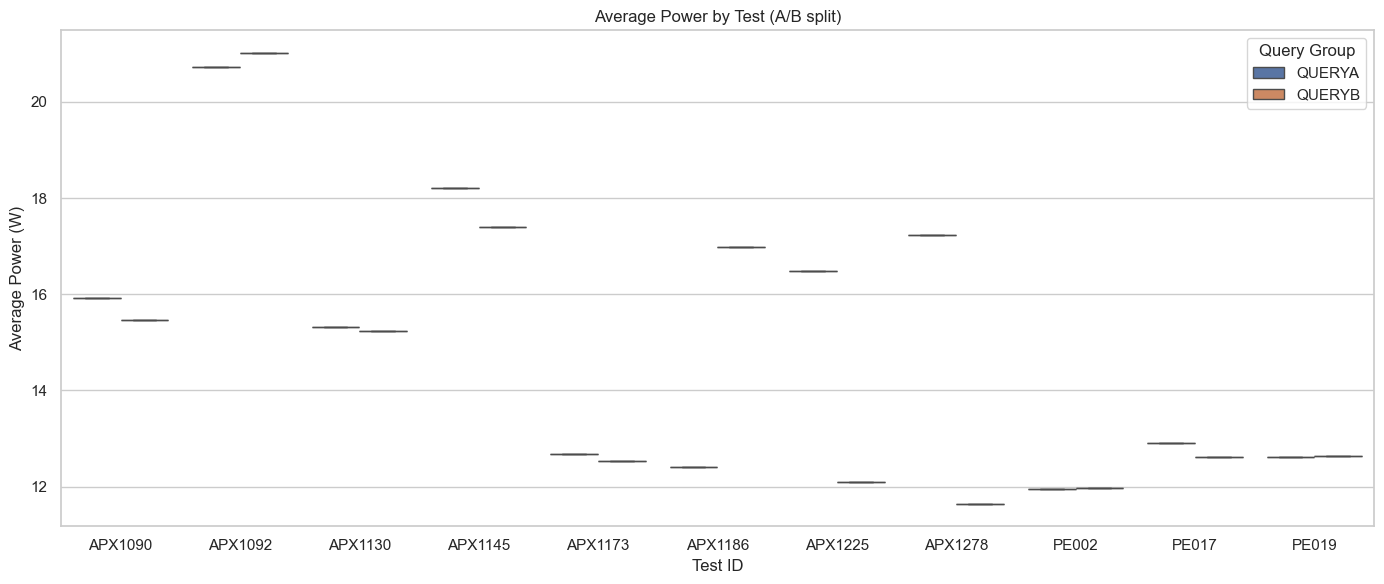

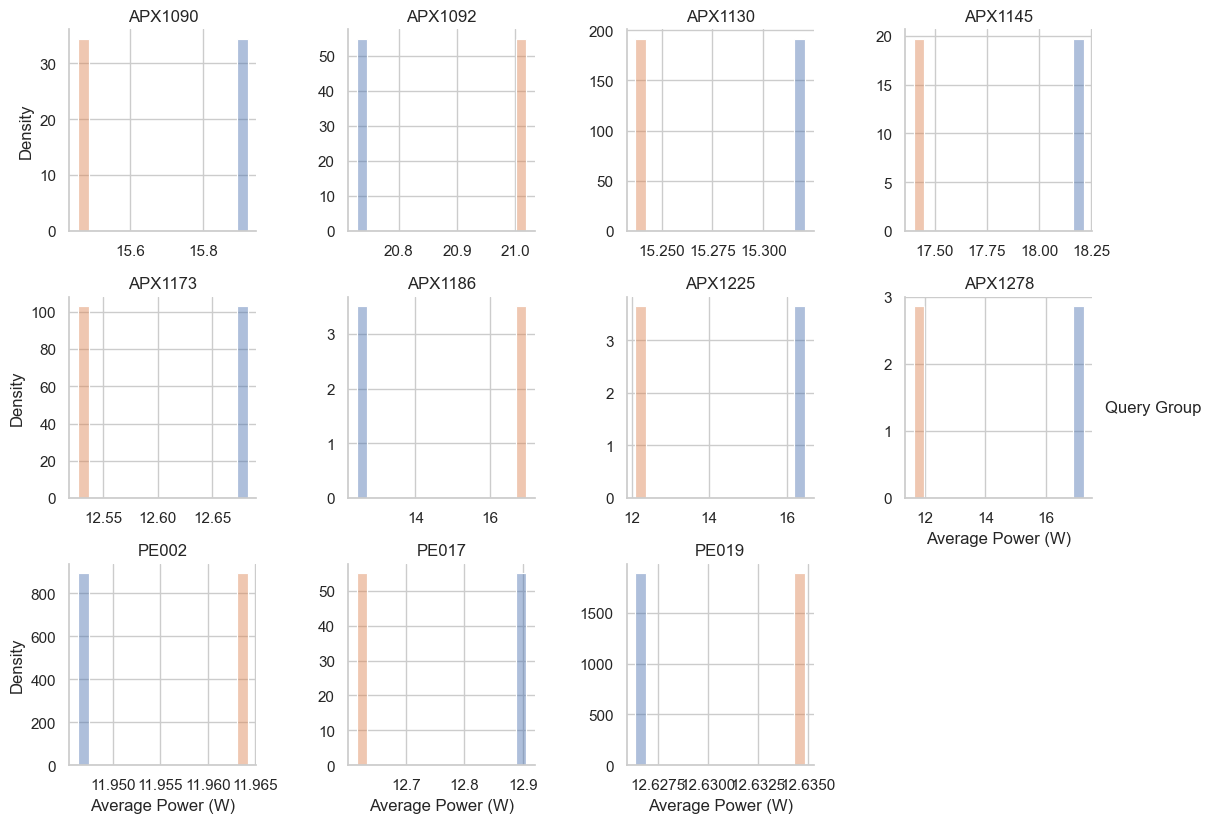

In [7]:
if analysis_df.empty:
    raise ValueError("No complete runs available for analysis.")

# Always show currently available run-level data, even if only one run exists.
summary_cols = [
    "run_id",
    "test",
    "query_group",
    "avg_power_w",
    "peak_power_w",
    "energy_j",
    "measured_window_sec",
    "power_samples",
]
available_summary_cols = [c for c in summary_cols if c in analysis_df.columns]

print("Run-level summary of available data:")
display(
    analysis_df[available_summary_cols]
    .sort_values([c for c in ["test", "run_id"] if c in analysis_df.columns])
    .reset_index(drop=True)
)

ab_df = analysis_df[analysis_df["query_group"].isin(["QUERYA", "QUERYB"])].copy()
groups_present = set(ab_df["query_group"].dropna().unique())

if {"QUERYA", "QUERYB"}.issubset(groups_present):
    print("Per-test A/B summary (avg_power_w):")
    display(
        ab_df.groupby(["test_id", "query_group"])["avg_power_w"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_index()
    )

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=ab_df, x="test_id", y="avg_power_w", hue="query_group")
    plt.title("Average Power by Test (A/B split)")
    plt.xlabel("Test ID")
    plt.ylabel("Average Power (W)")
    plt.legend(title="Query Group")
    plt.tight_layout()
    plt.show()

    g = sns.FacetGrid(ab_df, col="test_id", col_wrap=4, height=2.8, sharex=False, sharey=False)
    g.map_dataframe(sns.histplot, x="avg_power_w", hue="query_group", bins=16, stat="density", common_norm=False, alpha=0.45)
    g.add_legend(title="Query Group")
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Average Power (W)", "Density")
    plt.show()
else:
    print("A/B comparison plots will appear once both QUERYA and QUERYB runs are available.")

Permutation test results by test (A vs B within each test_id):


,test_id,n_queryA,n_queryB,observed_mean_diff_A_minus_B_w,p_left_A_lt_B,p_right_A_gt_B,p_two_sided
0,APX1090,1,1,0.465291,1.00000,0.50035,1.0
1,APX1092,1,1,-0.292445,0.50035,1.00000,1.0
2,APX1130,1,1,0.083652,1.00000,0.50035,1.0
3,APX1145,1,1,0.813420,1.00000,0.50035,1.0
4,APX1173,1,1,0.155413,1.00000,0.50035,1.0
5,APX1186,1,1,-4.566439,0.50035,1.00000,1.0
6,APX1225,1,1,4.383850,1.00000,0.50035,1.0
7,APX1278,1,1,5.587984,1.00000,0.50035,1.0
8,PE002,1,1,-0.017916,0.50035,1.00000,1.0
9,PE017,1,1,0.291121,1.00000,0.50035,1.0


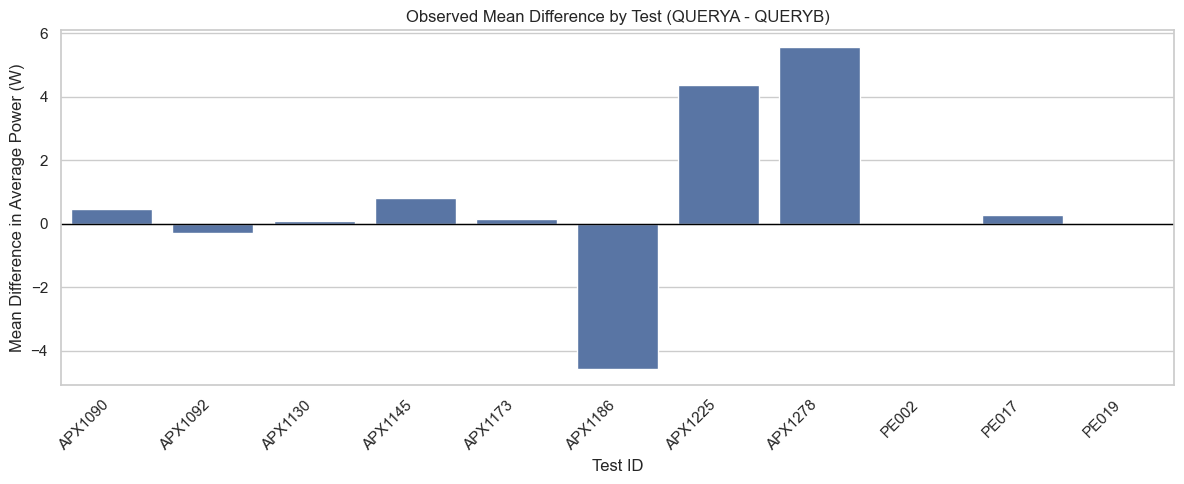

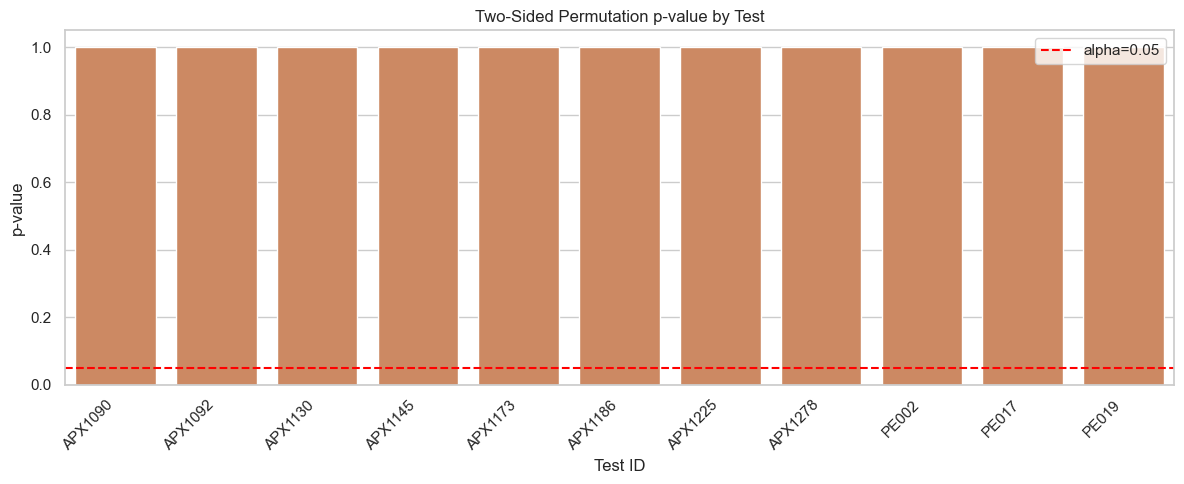

In [8]:
def permutation_test_mean_diff(df: pd.DataFrame, group_col: str, value_col: str, group_a: str, group_b: str, n_perm: int = 10000, seed: int = 42):
    a = df.loc[df[group_col] == group_a, value_col].dropna().to_numpy()
    b = df.loc[df[group_col] == group_b, value_col].dropna().to_numpy()

    if len(a) == 0 or len(b) == 0:
        raise ValueError(f"Missing data for one or both groups: {group_a}, {group_b}")

    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        diffs[i] = perm[:n_a].mean() - perm[n_a:].mean()

    p_left = (np.sum(diffs <= observed) + 1) / (n_perm + 1)
    p_right = (np.sum(diffs >= observed) + 1) / (n_perm + 1)
    p_two = (np.sum(np.abs(diffs) >= abs(observed)) + 1) / (n_perm + 1)

    return observed, p_left, p_right, p_two, diffs


ab_df = analysis_df[analysis_df["query_group"].isin(["QUERYA", "QUERYB"])].copy()
per_test_results = []
perm_diffs_by_test = {}

for test_id, test_group in ab_df.groupby("test_id"):
    groups_present = set(test_group["query_group"].dropna().unique())
    if not {"QUERYA", "QUERYB"}.issubset(groups_present):
        continue

    observed, p_left, p_right, p_two, perm_diffs = permutation_test_mean_diff(
        test_group,
        group_col="query_group",
        value_col="avg_power_w",
        group_a="QUERYA",
        group_b="QUERYB",
        n_perm=10000,
        seed=42,
    )

    perm_diffs_by_test[test_id] = perm_diffs
    per_test_results.append(
        {
            "test_id": test_id,
            "n_queryA": int((test_group["query_group"] == "QUERYA").sum()),
            "n_queryB": int((test_group["query_group"] == "QUERYB").sum()),
            "observed_mean_diff_A_minus_B_w": observed,
            "p_left_A_lt_B": p_left,
            "p_right_A_gt_B": p_right,
            "p_two_sided": p_two,
        }
    )

per_test_results_df = pd.DataFrame(per_test_results).sort_values("test_id")

if per_test_results_df.empty:
    print("No tests had both QUERYA and QUERYB for per-test A/B comparison.")
else:
    print("Permutation test results by test (A vs B within each test_id):")
    display(per_test_results_df)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=per_test_results_df, x="test_id", y="observed_mean_diff_A_minus_B_w", color="#4C72B0")
    plt.axhline(0.0, color="black", linewidth=1)
    plt.title("Observed Mean Difference by Test (QUERYA - QUERYB)")
    plt.xlabel("Test ID")
    plt.ylabel("Mean Difference in Average Power (W)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=per_test_results_df, x="test_id", y="p_two_sided", color="#DD8452")
    plt.axhline(0.05, color="red", linestyle="--", label="alpha=0.05")
    plt.title("Two-Sided Permutation p-value by Test")
    plt.xlabel("Test ID")
    plt.ylabel("p-value")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

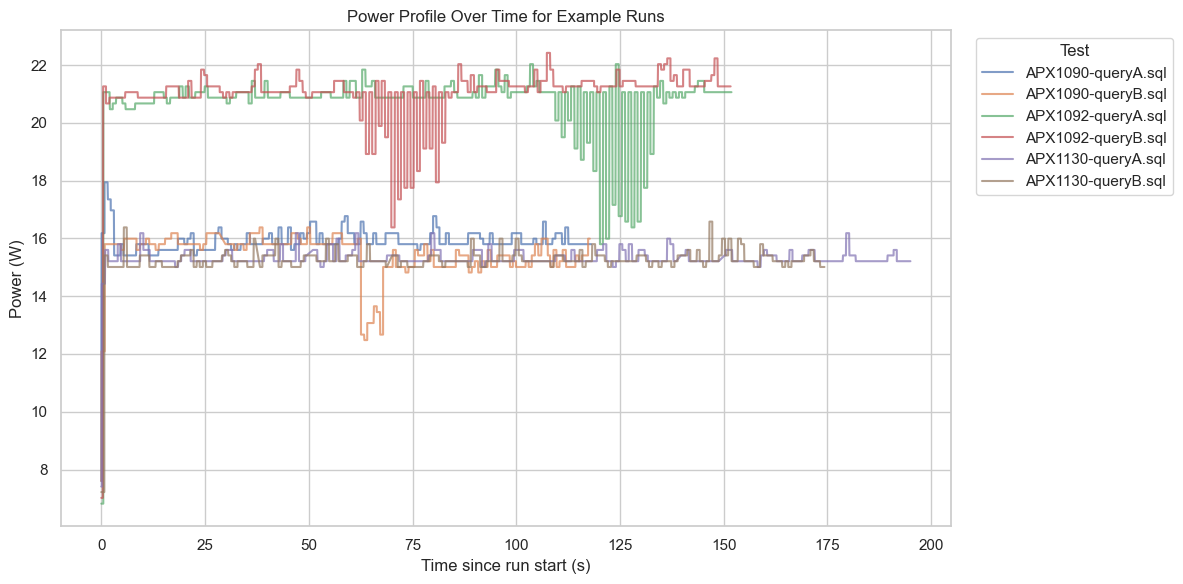

In [10]:
example_files = analysis_df["chunk_file"].dropna().head(6).tolist()

if example_files:
    profile_rows = []
    for file_name in example_files:
        chunk_df = pd.read_csv(file_name).sort_values("timestamp")
        chunk_df["time_s"] = (chunk_df["timestamp"] - chunk_df["timestamp"].min()) / 1000.0

        test_label = Path(file_name).name.split("__")[1] if "__" in Path(file_name).name else Path(file_name).stem
        chunk_df["test_label"] = test_label
        profile_rows.append(chunk_df)

    profile_df = pd.concat(profile_rows, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=profile_df, x="time_s", y="power_w", hue="test_label", estimator=None, alpha=0.7)
    plt.title("Power Profile Over Time for Example Runs")
    plt.xlabel("Time since run start (s)")
    plt.ylabel("Power (W)")
    plt.legend(title="Test", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No chunk files available for profile plot.")